# Mediation: APOE-independent set 57, ARHGAP35 expression in Ast.10, and Tau tangle level

## Aims
To test if ARHGAP35 expression in Ast.10 mediates the effect from the eQTLs to the Tau tangle level

## Main conclusions
All effects are non-significant results given the small sample size in `Ast_10_Kelli` dataset

## Input data
1. Genotype data:
 - original: `/mnt/lustre/lab/gwang/ftp_fgc_xqtl/ROSMAP/genotype/analysis_ready/geno_by_chrom/ROSMAP_NIA_WGS.leftnorm.bcftools_qc.plink_qc.19`
 - extracted: `/mnt/lustre/home/yl4437/xqtl_flagship/APOE/ROSMAP_geno_apoe4_indep_snps.vcf`
2. Ast.10 expression:
 - phenotype: `/mnt/lustre/lab/gwang/ftp_fgc_xqtl/eQTL/ROSMAP/Ast_10_Kelli/analysis_ready/phenotype_preprocessing/phenotype_by_chrom/snuc_pseudo_bulk.Ast.10.normalized.log2cpm.bed.chr19.bed.gz`
 - covariates: `/mnt/lustre/lab/gwang/ftp_fgc_xqtl/eQTL/ROSMAP/Ast_10_Kelli/analysis_ready/covariate_preprocessing/snuc_pseudo_bulk.Ast.10.normalized.log2cpm.rosmap_cov.ROSMAP_NIA_WGS.leftnorm.bcftools_qc.plink_qc.plink_qc.prune.pca.Marchenko_PC.gz`
3. Tau tangle level:
 - phenotype: `/mnt/lustre/home/yl4437/xqtl_flagship/APOE/ROSMAP_geno_apoecs_adpathology.csv.gz`
 - covariates: `msex`, `educ`, `age_death`, `apoe4_dose`, `apoe2_dose`

 **Questions:** Check covariate adjustment

In [61]:
library(data.table)
library(dplyr)
library(stringr)
library(tibble)
library(mediation)

setwd("/mnt/lustre/home/yl4437/xqtl_flagship/APOE")

## 1. Prepare the input

### Genotype data

In [12]:
# Check 2 variants in set 57: chr19:44827033_TGATAGATAGATAGATA_TGATA (APOE4/2_adj & APOE4_adj), chr19:44840322_G_A (APOE4/2_adj & APOE4_adj)
all_sets <- readRDS("/mnt/lustre/home/yl4437/xqtl_flagship/xqtl-paper/main_text/5_AD_xQTL_genes_cis_trans/figure_data/xqtl_only_APOE_all_cohorts_merged_cos_cs_after_between_purity.rds")
all_sets$final_pip_vcp[[57]]

[1] 0.5296667 0.4223633

In [34]:
geno <- fread('/mnt/lustre/home/yl4437/xqtl_flagship/APOE/ROSMAP_geno_apoe4_indep_snps.vcf')
geno <- melt(geno[,-c(6:9)],
             id.vars = c('#CHROM','POS','ID','REF','ALT'),
             variable.name = 'SID', value.name = 'geno')
geno[,dose:=str_count(geno, '1')]
head(geno)

#CHROM,POS,ID,REF,ALT,SID,geno,dose
<int>,<int>,<chr>,<chr>,<chr>,<fct>,<chr>,<int>
19,42994877,chr19:42994877_C_G,C,G,0_MAP15387421,0/0,0
19,43090637,chr19:43090637_G_T,G,T,0_MAP15387421,0/0,0
19,43337238,chr19:43337238_G_A,G,A,0_MAP15387421,0/0,0
19,43522968,chr19:43522968_T_C,T,C,0_MAP15387421,0/0,0
19,43632995,chr19:43632995_C_T,C,T,0_MAP15387421,0/0,0
19,43656997,chr19:43656997_G_A,G,A,0_MAP15387421,0/0,0


In [84]:
geno_44827033 <- geno %>% filter(ID == 'chr19:44827033_TGATAGATAGATAGATA_TGATA') %>% dplyr::select(SID, dose)
colnames(geno_44827033)[2] <- 'chr19_44827033_TGATAGATAGATAGATA_TGATA'
geno_44840322 <- geno %>% filter(ID == 'chr19:44840322_G_A') %>% dplyr::select(SID, dose)
colnames(geno_44840322)[2] <- 'chr19_44840322_G_A' 

In [85]:
geno_sub <- merge(geno_44827033, geno_44840322, by = 'SID')
geno_sub$SID <- str_remove(geno_sub$SID,'0_')
head(geno_sub); nrow(geno_sub); nrow(geno_44827033); nrow(geno_44840322)

SID,chr19_44827033_TGATAGATAGATAGATA_TGATA,chr19_44840322_G_A
<chr>,<int>,<int>
MAP15387421,0,0
MAP26637867,0,0
MAP29629849,0,1
MAP33332646,0,0
MAP34726040,0,0
MAP46246604,1,1


[1] 1153

[1] 1153

[1] 1153

### Ast.10 expression data

In [39]:
exp_pheno <- fread('/mnt/lustre/lab/gwang/ftp_fgc_xqtl/eQTL/ROSMAP/Ast_10_Kelli/analysis_ready/phenotype_preprocessing/phenotype_by_chrom/snuc_pseudo_bulk.Ast.10.normalized.log2cpm.bed.chr19.bed.gz')
exp_covar <- fread('/mnt/lustre/lab/gwang/ftp_fgc_xqtl/eQTL/ROSMAP/Ast_10_Kelli/analysis_ready/covariate_preprocessing/snuc_pseudo_bulk.Ast.10.normalized.log2cpm.rosmap_cov.ROSMAP_NIA_WGS.leftnorm.bcftools_qc.plink_qc.plink_qc.prune.pca.Marchenko_PC.gz')

In [41]:
exp_pheno_sub <- exp_pheno %>% filter(ID == 'ENSG00000160007') %>% 
                               dplyr::select(-`#chr`, -start, -end, -ID) %>%
                               t() %>%
                               as.data.frame(stringsAsFactors = FALSE) %>%
                               rownames_to_column("SID") %>% 
                               mutate(across(-SID, as.numeric))

colnames(exp_pheno_sub)[2] <- 'ARHGAP35_expression'
head(exp_pheno_sub)

,SID,ARHGAP35_expression
,<chr>,<dbl>
1,01211411,-1.0883905
2,SM-CTEET,1.2497740
3,SM-CJIZE,-0.5455637
4,SM-CTDR8,-0.4988484
5,SM-CTEER,-0.2156401
6,09841821,0.0305734


In [42]:
exp_covar_t <- exp_covar %>% 
  t() %>% 
  as.data.frame() %>% 
  rownames_to_column("SID")

colnames(exp_covar_t) <- exp_covar_t[1, ]
exp_covar_t <- exp_covar_t[-1, ]
colnames(exp_covar_t)[1] <- 'SID'
exp_covar_t <- exp_covar_t %>% mutate(across(-SID, as.numeric))

head(exp_covar_t)

,SID,msex,age_death,pmi,PC1,PC2,PC3,PC4,PC5,PC6,⋯,Hidden_Factor_PC13,Hidden_Factor_PC14,Hidden_Factor_PC15,Hidden_Factor_PC16,Hidden_Factor_PC17,Hidden_Factor_PC18,Hidden_Factor_PC19,Hidden_Factor_PC20,Hidden_Factor_PC21,Hidden_Factor_PC22
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
2,SM-CTEET,1,87.92882,4.333333,-0.0150772540,-0.004531332,0.053212535,0.06546143,-0.062968453,-0.007057172,⋯,-3.73272492,2.938498,-0.46786556,0.8110002,-1.0526366,4.8234144,-4.464254,6.09556284,-4.976386,0.8997396
3,SM-CTDR8,1,94.06982,4.166667,-0.0149788950,-0.083481930,-0.036837963,0.02971291,-0.011343449,0.060045336,⋯,-3.82715854,-3.654555,-2.93347325,3.2216772,-2.3848423,-6.0134396,-1.362644,-8.75252462,-7.004478,0.9005868
4,SM-CTEER,1,89.46749,7.583333,0.0001260455,-0.004010259,0.005968028,-0.11639666,0.005224582,-0.013513300,⋯,2.87743420,2.244435,-0.32362208,-4.2874232,-5.3764331,-0.9070111,4.445538,-5.40860481,-2.891068,4.0887165
5,SM-CTEF8,1,83.39767,7.583333,0.0263008380,-0.100683611,0.068988084,0.03517509,-0.077908178,-0.093337722,⋯,0.07105738,-3.687757,-0.04245612,0.2682807,-3.2440065,-2.0043249,-3.097644,0.18240311,4.178432,-3.3927885
6,SM-CJGI5,1,89.71389,13.250000,-0.0779839480,0.006979027,0.118239036,-0.06749283,0.092815585,0.115507964,⋯,-0.66765690,2.688590,3.71286195,-1.1901165,-0.3629666,1.6517601,-9.072958,4.81726515,4.206375,-2.4506800
7,SM-CJEIA,1,108.28200,9.916667,-0.0808382950,-0.085717391,0.083149866,-0.01509437,0.143605219,-0.069029353,⋯,9.72653319,1.435999,-3.82086303,-2.9400806,-4.6450254,-1.8854356,-1.206931,0.04852288,5.206071,5.5372335


In [58]:
exp <- merge(exp_pheno_sub, exp_covar_t, by = 'SID')
head(exp); nrow(exp)

,SID,ARHGAP35_expression,msex,age_death,pmi,PC1,PC2,PC3,PC4,PC5,⋯,Hidden_Factor_PC13,Hidden_Factor_PC14,Hidden_Factor_PC15,Hidden_Factor_PC16,Hidden_Factor_PC17,Hidden_Factor_PC18,Hidden_Factor_PC19,Hidden_Factor_PC20,Hidden_Factor_PC21,Hidden_Factor_PC22
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,MAP34726040,-1.5812489,1,72.82683,4.666667,-0.052324370,0.011045540,0.0246338400,0.08858472,0.04052422,⋯,-6.6081109,-5.8643786,-16.251409,7.249524,13.4804109,-21.844780,17.0300696,4.2259170,0.3653650,-1.50494813
2,ROS11430815,-0.1328539,1,86.58727,1.250000,-0.109689106,-0.010092409,-0.1304692290,-0.12401295,-0.16148739,⋯,-4.5424168,-2.0650016,-1.698718,-1.301760,-3.3475648,-1.247581,-0.2067585,4.5353877,-0.8368590,0.82806823
3,ROS21112011,0.2156401,0,91.46064,5.750000,-0.012449771,-0.094950139,0.0064859580,0.07039917,0.20084300,⋯,4.0060401,9.4241864,-1.646698,3.834887,0.9297217,4.995949,2.4382327,0.4225704,-3.4779741,-4.34455316
4,SM-CJEFU,2.1379559,1,81.93840,8.833333,0.021598780,0.129671550,0.1814347200,-0.21919708,-0.10524016,⋯,-1.0323908,-7.3391139,2.924691,-1.287809,4.9251049,7.172916,-3.7843055,2.3035009,-2.9835314,0.02291471
5,SM-CJEI5,1.8449786,1,91.36482,8.600000,0.004015053,0.104765235,0.2159364300,-0.03264320,0.05691283,⋯,2.7847260,-3.5998832,5.289030,-13.196968,16.4835266,-7.468307,-17.6495016,3.1959290,-2.4872432,8.56234037
6,SM-CJEI6,-0.1740978,1,81.57974,6.750000,0.001383011,0.004188652,-0.0001817509,-0.06164207,0.03976851,⋯,0.8304298,0.6945706,-2.107982,-1.426689,0.2243149,-2.082802,-5.1258090,0.3689022,0.1651449,-4.30877500


[1] 113

### Tau pathology data

In [44]:
patho <- fread('/mnt/lustre/home/yl4437/xqtl_flagship/APOE/ROSMAP_geno_apoecs_adpathology.csv.gz')

In [59]:
patho_sub <- patho %>% filter(cs_id == 'set_57') %>% dplyr::select(specimenID, tangles_sqrt, educ, apoe4_dose, apoe2_dose, msex, age_death, pmi, ROS_study)
patho_sub <- unique(patho_sub)
colnames(patho_sub) <- c('SID', "tangles_sqrt", "apoe4_dose", "apoe2_dose", "educ", "msex_p", "age_death_p", "pmi_p", "ROS_study")

In [62]:
head(patho_sub); nrow(patho_sub)

SID,tangles_sqrt,apoe4_dose,apoe2_dose,educ,msex_p,age_death_p,pmi_p,ROS_study
<chr>,<dbl>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<int>
SM-CJFK8,2.218849,16,0,0,0,100.87340,7.500000,0
SM-CTDUU,4.143426,16,1,0,0,80.65708,5.500000,0
SM-CTDSC,2.516578,12,0,1,0,83.69062,3.933333,0
SM-CJIYB,3.815742,15,0,0,1,92.61875,5.083333,0
SM-CTEMS,2.196057,12,0,0,0,90.38467,3.783333,0
SM-CJFLR,5.088562,15,0,0,0,94.31348,5.000000,0


[1] 1113

### Merge the input

In [98]:
# Overlapping samples only for traditional mediation analysis
input <- merge(geno_sub, exp, by = "SID")
input <- merge(input, patho_sub, by = "SID")
summary(input)

     SID            chr19_44827033_TGATAGATAGATAGATA_TGATA chr19_44840322_G_A
 Length:110         Min.   :0.0000                         Min.   :0.0000    
 Class :character   1st Qu.:0.0000                         1st Qu.:0.0000    
 Mode  :character   Median :0.0000                         Median :0.0000    
                    Mean   :0.2545                         Mean   :0.2455    
                    3rd Qu.:0.0000                         3rd Qu.:0.0000    
                    Max.   :2.0000                         Max.   :2.0000    
                                                                             
 ARHGAP35_expression      msex          age_death           pmi        
 Min.   :-2.403023   Min.   :0.0000   Min.   : 73.79   Min.   : 1.000  
 1st Qu.:-0.687380   1st Qu.:0.0000   1st Qu.: 83.90   1st Qu.: 4.392  
 Median : 0.000000   Median :0.0000   Median : 88.47   Median : 6.192  
 Mean   :-0.003125   Mean   :0.4182   Mean   : 88.26   Mean   : 6.786  
 3rd Qu.: 0.6617

In [100]:
input <- input[complete.cases(input[, c("tangles_sqrt", "apoe2_dose", "educ")]), ]
colnames(input); nrow(input); nrow(geno_sub); nrow(exp); nrow(patho_sub)

[1] "SID"                                   
 [2] "chr19_44827033_TGATAGATAGATAGATA_TGATA"
 [3] "chr19_44840322_G_A"                    
 [4] "ARHGAP35_expression"                   
 [5] "msex"                                  
 [6] "age_death"                             
 [7] "pmi"                                   
 [8] "PC1"                                   
 [9] "PC2"                                   
[10] "PC3"                                   
[11] "PC4"                                   
[12] "PC5"                                   
[13] "PC6"                                   
[14] "PC7"                                   
[15] "PC8"                                   
[16] "PC9"                                   
[17] "PC10"                                  
[18] "PC11"                                  
[19] "PC12"                                  
[20] "PC13"                                  
[21] "PC14"                                  
[22] "PC15"                                  
[23] "Hidden_Factor_PC1"                     
[24] "Hidden_Factor_PC2"                     
[25] "Hidden_Factor_PC3"                     
[26] "Hidden_Factor_PC4"                     
[27] "Hidden_Factor_PC5"                     
[28] "Hidden_Factor_PC6"                     
[29] "Hidden_Factor_PC7"                     
[30] "Hidden_Factor_PC8"                     
[31] "Hidden_Factor_PC9"                     
[32] "Hidden_Factor_PC10"                    
[33] "Hidden_Factor_PC11"                    
[34] "Hidden_Factor_PC12"                    
[35] "Hidden_Factor_PC13"                    
[36] "Hidden_Factor_PC14"                    
[37] "Hidden_Factor_PC15"                    
[38] "Hidden_Factor_PC16"                    
[39] "Hidden_Factor_PC17"                    
[40] "Hidden_Factor_PC18"                    
[41] "Hidden_Factor_PC19"                    
[42] "Hidden_Factor_PC20"                    
[43] "Hidden_Factor_PC21"                    
[44] "Hidden_Factor_PC22"                    
[45] "tangles_sqrt"                          
[46] "apoe4_dose"                            
[47] "apoe2_dose"                            
[48] "educ"                                  
[49] "msex_p"                                
[50] "age_death_p"                           
[51] "pmi_p"                                 
[52] "ROS_study"

[1] 107

[1] 1153

[1] 113

[1] 1113

In [87]:
# Partially overlapping samples for FIML-SEM mediation analysis
input_all <- merge(geno_sub, exp, by = "SID", all = TRUE)
input_all <- merge(input_all, patho_sub, by = "SID", all = TRUE)
colnames(input_all); nrow(input_all)

[1] "SID"                                   
 [2] "chr19_44827033_TGATAGATAGATAGATA_TGATA"
 [3] "chr19_44840322_G_A"                    
 [4] "ARHGAP35_expression"                   
 [5] "msex"                                  
 [6] "age_death"                             
 [7] "pmi"                                   
 [8] "PC1"                                   
 [9] "PC2"                                   
[10] "PC3"                                   
[11] "PC4"                                   
[12] "PC5"                                   
[13] "PC6"                                   
[14] "PC7"                                   
[15] "PC8"                                   
[16] "PC9"                                   
[17] "PC10"                                  
[18] "PC11"                                  
[19] "PC12"                                  
[20] "PC13"                                  
[21] "PC14"                                  
[22] "PC15"                                  
[23] "Hidden_Factor_PC1"                     
[24] "Hidden_Factor_PC2"                     
[25] "Hidden_Factor_PC3"                     
[26] "Hidden_Factor_PC4"                     
[27] "Hidden_Factor_PC5"                     
[28] "Hidden_Factor_PC6"                     
[29] "Hidden_Factor_PC7"                     
[30] "Hidden_Factor_PC8"                     
[31] "Hidden_Factor_PC9"                     
[32] "Hidden_Factor_PC10"                    
[33] "Hidden_Factor_PC11"                    
[34] "Hidden_Factor_PC12"                    
[35] "Hidden_Factor_PC13"                    
[36] "Hidden_Factor_PC14"                    
[37] "Hidden_Factor_PC15"                    
[38] "Hidden_Factor_PC16"                    
[39] "Hidden_Factor_PC17"                    
[40] "Hidden_Factor_PC18"                    
[41] "Hidden_Factor_PC19"                    
[42] "Hidden_Factor_PC20"                    
[43] "Hidden_Factor_PC21"                    
[44] "Hidden_Factor_PC22"                    
[45] "tangles_sqrt"                          
[46] "apoe4_dose"                            
[47] "apoe2_dose"                            
[48] "educ"                                  
[49] "msex_p"                                
[50] "age_death_p"                           
[51] "pmi_p"                                 
[52] "ROS_study"

[1] 1153

In [72]:
# Create unified covariates — msex/age_death/pmi
idx1 <- !is.na(input_all$msex) & !is.na(input_all$msex_p)
input_all$msex[idx1] == input_all$msex_p[idx1]

[1] TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE
 [16] TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE
 [31] TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE
 [46] TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE
 [61] TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE
 [76] TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE
 [91] TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE
[106] TRUE TRUE TRUE TRUE TRUE

In [ ]:
idx2 <- !is.na(input_all$age_death) & !is.na(input_all$age_death_p)
input_all$age_death[idx2] == input_all$age_death_p[idx2] # Rounding issues

[1] FALSE FALSE  TRUE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE
 [13] FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE
 [25] FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE
 [37] FALSE FALSE FALSE  TRUE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE
 [49] FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE  TRUE FALSE FALSE
 [61] FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE
 [73] FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE
 [85] FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE
 [97]  TRUE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE
[109] FALSE FALSE

In [ ]:
idx3 <- !is.na(input_all$pmi) & !is.na(input_all$pmi_p)
input_all$pmi[idx3] == input_all$pmi_p[idx3] # Rounding issues

[1] FALSE  TRUE  TRUE FALSE  TRUE FALSE  TRUE FALSE  TRUE FALSE FALSE  TRUE
 [13]  TRUE  TRUE FALSE  TRUE FALSE FALSE  TRUE FALSE  TRUE FALSE FALSE  TRUE
 [25]  TRUE FALSE FALSE  TRUE FALSE  TRUE FALSE  TRUE FALSE FALSE FALSE FALSE
 [37] FALSE FALSE  TRUE FALSE FALSE FALSE FALSE FALSE  TRUE FALSE  TRUE  TRUE
 [49]  TRUE FALSE FALSE FALSE  TRUE FALSE  TRUE FALSE  TRUE  TRUE FALSE FALSE
 [61]  TRUE FALSE FALSE FALSE  TRUE  TRUE  TRUE FALSE  TRUE FALSE FALSE  TRUE
 [73]  TRUE FALSE  TRUE FALSE  TRUE  TRUE  TRUE FALSE  TRUE FALSE FALSE  TRUE
 [85] FALSE  TRUE FALSE  TRUE FALSE FALSE FALSE  TRUE FALSE FALSE  TRUE FALSE
 [97]  TRUE FALSE FALSE FALSE FALSE  TRUE  TRUE  TRUE FALSE FALSE FALSE  TRUE
[109] FALSE FALSE

In [88]:
input_all$msex_u  <- ifelse(!is.na(input_all$msex), input_all$msex, input_all$msex_p)
input_all$age_death_u   <- ifelse(!is.na(input_all$age_death), input_all$age_death, input_all$age_death_p)
input_all$pmi_u   <- ifelse(!is.na(input_all$pmi), input_all$pmi, input_all$pmi_p)

input_all_out <- input_all %>% dplyr::select(-c(msex, msex_p, age_death, age_death_p, pmi, pmi_p))
colnames(input_all_out); nrow(input_all_out)

[1] "SID"                                   
 [2] "chr19_44827033_TGATAGATAGATAGATA_TGATA"
 [3] "chr19_44840322_G_A"                    
 [4] "ARHGAP35_expression"                   
 [5] "PC1"                                   
 [6] "PC2"                                   
 [7] "PC3"                                   
 [8] "PC4"                                   
 [9] "PC5"                                   
[10] "PC6"                                   
[11] "PC7"                                   
[12] "PC8"                                   
[13] "PC9"                                   
[14] "PC10"                                  
[15] "PC11"                                  
[16] "PC12"                                  
[17] "PC13"                                  
[18] "PC14"                                  
[19] "PC15"                                  
[20] "Hidden_Factor_PC1"                     
[21] "Hidden_Factor_PC2"                     
[22] "Hidden_Factor_PC3"                     
[23] "Hidden_Factor_PC4"                     
[24] "Hidden_Factor_PC5"                     
[25] "Hidden_Factor_PC6"                     
[26] "Hidden_Factor_PC7"                     
[27] "Hidden_Factor_PC8"                     
[28] "Hidden_Factor_PC9"                     
[29] "Hidden_Factor_PC10"                    
[30] "Hidden_Factor_PC11"                    
[31] "Hidden_Factor_PC12"                    
[32] "Hidden_Factor_PC13"                    
[33] "Hidden_Factor_PC14"                    
[34] "Hidden_Factor_PC15"                    
[35] "Hidden_Factor_PC16"                    
[36] "Hidden_Factor_PC17"                    
[37] "Hidden_Factor_PC18"                    
[38] "Hidden_Factor_PC19"                    
[39] "Hidden_Factor_PC20"                    
[40] "Hidden_Factor_PC21"                    
[41] "Hidden_Factor_PC22"                    
[42] "tangles_sqrt"                          
[43] "apoe4_dose"                            
[44] "apoe2_dose"                            
[45] "educ"                                  
[46] "ROS_study"                             
[47] "msex_u"                                
[48] "age_death_u"                           
[49] "pmi_u"

[1] 1153

In [89]:
write.table(input_all_out, file = '/mnt/lustre/home/yl4437/xqtl_flagship/APOE/mediation_partialoverlap_claude/APOE_ind_set_57_mediation_all_input.txt',
            quote = FALSE, sep = '\t', col.names = TRUE, row.names = FALSE)

## 2. Mediation: chr19:44827033_TGATAGATAGATAGATA_TGATA -> ARHGAP35 exp in Ast.10 -> Tau level

In [104]:
mod1.1 <- lm(ARHGAP35_expression ~ chr19_44827033_TGATAGATAGATAGATA_TGATA + msex + age_death + pmi, data = input)
mod1.2 <- lm(tangles_sqrt ~ chr19_44827033_TGATAGATAGATAGATA_TGATA + ARHGAP35_expression + msex + age_death + educ + apoe4_dose + apoe2_dose, data = input)

In [105]:
mod_mediat1 <- mediate(mod1.1, mod1.2, sims = 1000, boot = TRUE, boot.ci.type = "perc",
                       treat = "chr19_44827033_TGATAGATAGATAGATA_TGATA", mediator = "ARHGAP35_expression", conf.level = 0.95)

Running nonparametric bootstrap




In [106]:
summary(mod_mediat1)


Causal Mediation Analysis 

Nonparametric Bootstrap Confidence Intervals with the Percentile Method

                 Estimate 95% CI Lower 95% CI Upper p-value
ACME            0.0111595   -0.0759331    0.1505477   0.820
ADE             0.0040875   -0.6774749    0.5794065   0.962
Total Effect    0.0152470   -0.6808906    0.5819206   0.992
Prop. Mediated  0.7319123   -2.0583794    1.7147752   0.948

Sample Size Used: 107 


Simulations: 1000 


### Visualization

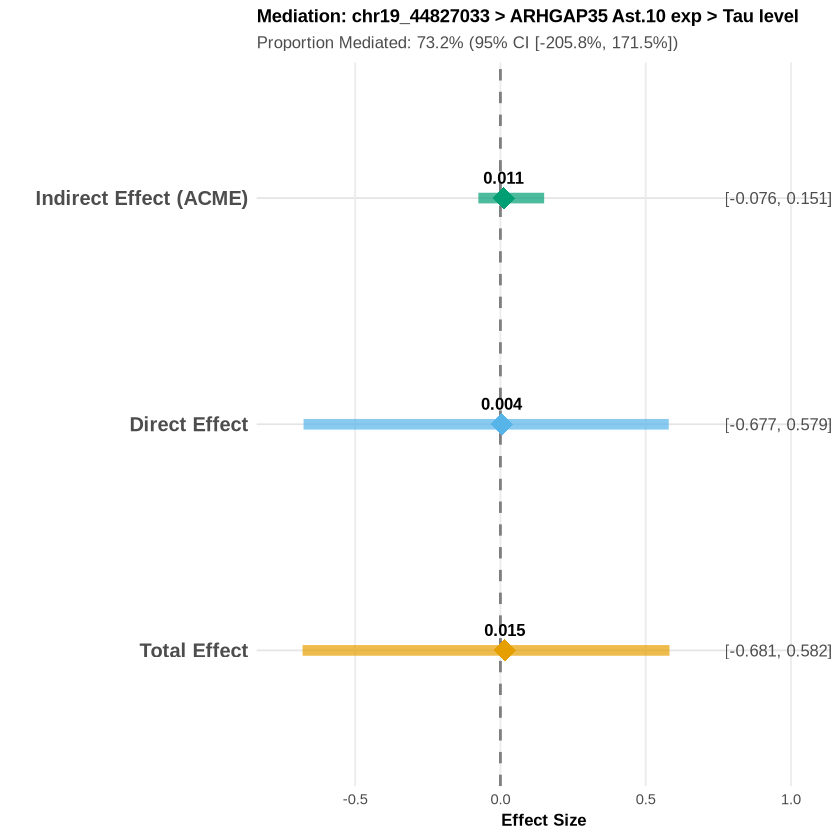

In [148]:
library(ggplot2)
library(dplyr)

# Extract results into a dataframe
mediation_results <- data.frame(
  effect_type = factor(c("Total Effect", "Direct Effect", "Indirect Effect (ACME)"),
                       levels = c("Total Effect", "Direct Effect", "Indirect Effect (ACME)")),
  estimate = c(mod_mediat1$tau.coef,       # Total effect
               mod_mediat1$z.avg,          # Direct effect (ADE)
               mod_mediat1$d.avg),         # Indirect effect (ACME)
  ci_lower = c(mod_mediat1$tau.ci[1],
               mod_mediat1$z.avg.ci[1],
               mod_mediat1$d.avg.ci[1]),
  ci_upper = c(mod_mediat1$tau.ci[2],
               mod_mediat1$z.avg.ci[2],
               mod_mediat1$d.avg.ci[2]),
  p_value = c(mod_mediat1$tau.p,
              mod_mediat1$z.avg.p,
              mod_mediat1$d.avg.p),
  stringsAsFactors = FALSE
)

# Calculate standard errors
mediation_results <- mediation_results %>%
  mutate(
    se = (ci_upper - ci_lower) / (2 * 1.96),
    significance = ifelse(p_value < 0.001, "***",
                          ifelse(p_value < 0.01, "**",
                                 ifelse(p_value < 0.05, "*", "ns")))
  )

# Publication-ready table plot
p_table <- ggplot(mediation_results, aes(y = effect_type)) +
  geom_vline(xintercept = 0, linetype = "dashed", color = "gray50", linewidth = 0.8) +
  geom_segment(aes(x = ci_lower, xend = ci_upper, 
                   y = effect_type, yend = effect_type, color = effect_type),
               linewidth = 3, alpha = 0.7) +
  geom_point(aes(x = estimate, color = effect_type), size = 6, shape = 18) +
  geom_text(aes(x = estimate, label = sprintf("%.3f", estimate)),
            vjust = -1.2, size = 3.5, fontface = "bold") +
  geom_text(aes(x = max(ci_upper) + (max(ci_upper) - min(ci_lower)) * 0.15,
                label = sprintf("[%.3f, %.3f]", ci_lower, ci_upper)),
            size = 3.5, hjust = 0, color = "gray30") +
  geom_text(aes(x = max(ci_upper) + (max(ci_upper) - min(ci_lower)) * 0.5,
                label = sprintf("p %s %s", 
                                ifelse(p_value < 0.001, "<", "="),
                                ifelse(p_value < 0.001, "0.001", sprintf("%.3f", p_value)))),
            size = 3.5, hjust = 0, color = "black", fontface = "bold") +
  scale_color_manual(values = c("Total Effect" = "#E69F00", 
                                "Direct Effect" = "#56B4E9", 
                                "Indirect Effect (ACME)" = "#009E73")) +
  labs(
    title = "Mediation: chr19_44827033 > ARHGAP35 Ast.10 exp > Tau level",
    subtitle = sprintf("Proportion Mediated: %.1f%% (95%% CI [%.1f%%, %.1f%%])", 
                       mod_mediat1$n.avg * 100,
                       mod_mediat1$n.avg.ci[1] * 100,
                       mod_mediat1$n.avg.ci[2] * 100),
    x = "Effect Size",
    y = ""
  ) +
  theme_minimal() +
  theme(
    legend.position = "none",
    panel.grid.major.y = element_line(color = "gray90"),
    panel.grid.minor = element_blank(),
    axis.text.y = element_text(size = 12, face = "bold"),
    axis.title.x = element_text(face = "bold", size = 10),
    plot.title = element_text(face = "bold", size = 11),
    plot.subtitle = element_text(size = 10, color = "gray30")
  ) +
  coord_cartesian(xlim = c(min(mediation_results$ci_lower) * 1.1,
                           max(mediation_results$ci_upper) * 1.8))

print(p_table)

## 3. Mediation: chr19:44840322_G_A -> ARHGAP35 exp in Ast.10 -> Tau level

In [109]:
mod2.1 <- lm(ARHGAP35_expression ~ chr19_44840322_G_A + msex + age_death + pmi, data = input)
mod2.2 <- lm(tangles_sqrt ~ chr19_44840322_G_A + ARHGAP35_expression + msex + age_death + educ + apoe4_dose + apoe2_dose, data = input)

In [110]:
mod_mediat2 <- mediate(mod2.1, mod2.2, sims = 1000, boot = TRUE, boot.ci.type = "perc",
                       treat = "chr19_44840322_G_A", mediator = "ARHGAP35_expression", conf.level = 0.95)

Running nonparametric bootstrap




In [111]:
summary(mod_mediat2)


Causal Mediation Analysis 

Nonparametric Bootstrap Confidence Intervals with the Percentile Method

               Estimate 95% CI Lower 95% CI Upper p-value
ACME            0.01503     -0.06656      0.16927   0.702
ADE            -0.11997     -0.79300      0.49698   0.704
Total Effect   -0.10494     -0.75221      0.51499   0.772
Prop. Mediated -0.14323     -1.73393      1.77628   0.926

Sample Size Used: 107 


Simulations: 1000 


### Visualization

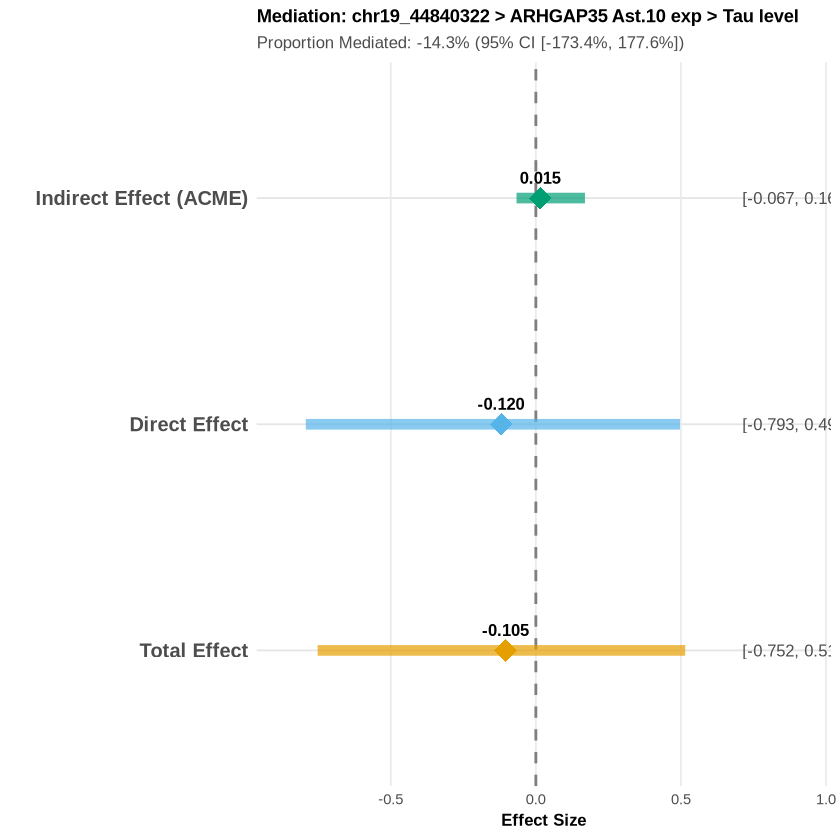

In [149]:
library(ggplot2)
library(dplyr)

# Extract results into a dataframe
mediation_results <- data.frame(
  effect_type = factor(c("Total Effect", "Direct Effect", "Indirect Effect (ACME)"),
                       levels = c("Total Effect", "Direct Effect", "Indirect Effect (ACME)")),
  estimate = c(mod_mediat2$tau.coef,       # Total effect
               mod_mediat2$z.avg,          # Direct effect (ADE)
               mod_mediat2$d.avg),         # Indirect effect (ACME)
  ci_lower = c(mod_mediat2$tau.ci[1],
               mod_mediat2$z.avg.ci[1],
               mod_mediat2$d.avg.ci[1]),
  ci_upper = c(mod_mediat2$tau.ci[2],
               mod_mediat2$z.avg.ci[2],
               mod_mediat2$d.avg.ci[2]),
  p_value = c(mod_mediat2$tau.p,
              mod_mediat2$z.avg.p,
              mod_mediat2$d.avg.p),
  stringsAsFactors = FALSE
)

# Calculate standard errors
mediation_results <- mediation_results %>%
  mutate(
    se = (ci_upper - ci_lower) / (2 * 1.96),
    significance = ifelse(p_value < 0.001, "***",
                          ifelse(p_value < 0.01, "**",
                                 ifelse(p_value < 0.05, "*", "ns")))
  )

# Publication-ready table plot
p_table <- ggplot(mediation_results, aes(y = effect_type)) +
  geom_vline(xintercept = 0, linetype = "dashed", color = "gray50", linewidth = 0.8) +
  geom_segment(aes(x = ci_lower, xend = ci_upper, 
                   y = effect_type, yend = effect_type, color = effect_type),
               linewidth = 3, alpha = 0.7) +
  geom_point(aes(x = estimate, color = effect_type), size = 6, shape = 18) +
  geom_text(aes(x = estimate, label = sprintf("%.3f", estimate)),
            vjust = -1.2, size = 3.5, fontface = "bold") +
  geom_text(aes(x = max(ci_upper) + (max(ci_upper) - min(ci_lower)) * 0.15,
                label = sprintf("[%.3f, %.3f]", ci_lower, ci_upper)),
            size = 3.5, hjust = 0, color = "gray30") +
  geom_text(aes(x = max(ci_upper) + (max(ci_upper) - min(ci_lower)) * 0.5,
                label = sprintf("p %s %s", 
                                ifelse(p_value < 0.001, "<", "="),
                                ifelse(p_value < 0.001, "0.001", sprintf("%.3f", p_value)))),
            size = 3.5, hjust = 0, color = "black", fontface = "bold") +
  scale_color_manual(values = c("Total Effect" = "#E69F00", 
                                "Direct Effect" = "#56B4E9", 
                                "Indirect Effect (ACME)" = "#009E73")) +
  labs(
    title = "Mediation: chr19_44840322 > ARHGAP35 Ast.10 exp > Tau level",
    subtitle = sprintf("Proportion Mediated: %.1f%% (95%% CI [%.1f%%, %.1f%%])", 
                       mod_mediat2$n.avg * 100,
                       mod_mediat2$n.avg.ci[1] * 100,
                       mod_mediat2$n.avg.ci[2] * 100),
    x = "Effect Size",
    y = ""
  ) +
  theme_minimal() +
  theme(
    legend.position = "none",
    panel.grid.major.y = element_line(color = "gray90"),
    panel.grid.minor = element_blank(),
    axis.text.y = element_text(size = 12, face = "bold"),
    axis.title.x = element_text(face = "bold", size = 10),
    plot.title = element_text(face = "bold", size = 11),
    plot.subtitle = element_text(size = 10, color = "gray30")
  ) +
  coord_cartesian(xlim = c(min(mediation_results$ci_lower) * 1.1,
                           max(mediation_results$ci_upper) * 1.8))

print(p_table)

## 4. Compare with association results

In [143]:
# Excluding expression data
input_noexp <- merge(geno_sub, patho_sub, by = "SID")
nrow(input); nrow(input_noexp)

[1] 107

[1] 1113

In [144]:
cp1.1 <- lm(tangles_sqrt ~ chr19_44827033_TGATAGATAGATAGATA_TGATA + msex_p + age_death_p + educ + apoe4_dose + apoe2_dose, data = input)
cp1.2 <- lm(tangles_sqrt ~ chr19_44827033_TGATAGATAGATAGATA_TGATA + msex_p + age_death_p + educ + apoe4_dose + apoe2_dose, data = input_noexp)

In [145]:
summary(cp1.1); summary(cp1.2)


Call:
lm(formula = tangles_sqrt ~ chr19_44827033_TGATAGATAGATAGATA_TGATA + 
    msex_p + age_death_p + educ + apoe4_dose + apoe2_dose, data = input)

Residuals:
    Min      1Q  Median      3Q     Max 
-2.5725 -1.0312 -0.3048  1.0347  4.6640 

Coefficients:
                                       Estimate Std. Error t value Pr(>|t|)  
(Intercept)                             0.73830    2.21985   0.333   0.7401  
chr19_44827033_TGATAGATAGATAGATA_TGATA  0.01597    0.33184   0.048   0.9617  
msex_p                                 -0.58628    0.30406  -1.928   0.0567 .
age_death_p                             0.01689    0.02351   0.719   0.4741  
educ                                   -0.63715    0.40762  -1.563   0.1212  
apoe4_dose                              0.02613    0.04185   0.624   0.5338  
apoe2_dose                              0.72758    0.29088   2.501   0.0140 *
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 1.489 on 100 degrees of 


Call:
lm(formula = tangles_sqrt ~ chr19_44827033_TGATAGATAGATAGATA_TGATA + 
    msex_p + age_death_p + educ + apoe4_dose + apoe2_dose, data = input_noexp)

Residuals:
    Min      1Q  Median      3Q     Max 
-2.6781 -0.8255 -0.1187  0.6398  5.9036 

Coefficients:
                                        Estimate Std. Error t value Pr(>|t|)
(Intercept)                            -0.785473   0.574067  -1.368 0.171522
chr19_44827033_TGATAGATAGATAGATA_TGATA -0.290016   0.080658  -3.596 0.000339
msex_p                                 -0.393234   0.080985  -4.856 1.38e-06
age_death_p                             0.040150   0.005889   6.817 1.56e-11
educ                                   -0.411394   0.099878  -4.119 4.10e-05
apoe4_dose                             -0.030537   0.010710  -2.851 0.004439
apoe2_dose                              0.773136   0.079098   9.774  < 2e-16
                                          
(Intercept)                               
chr19_44827033_TGATAGATAGATAGATA_

In [146]:
cp2.1 <- lm(tangles_sqrt ~ chr19_44840322_G_A + msex_p + age_death_p + educ + apoe4_dose + apoe2_dose, data = input)
cp2.2 <- lm(tangles_sqrt ~ chr19_44840322_G_A + msex_p + age_death_p + educ + apoe4_dose + apoe2_dose, data = input_noexp)

In [147]:
summary(cp2.1); summary(cp2.2)


Call:
lm(formula = tangles_sqrt ~ chr19_44840322_G_A + msex_p + age_death_p + 
    educ + apoe4_dose + apoe2_dose, data = input)

Residuals:
    Min      1Q  Median      3Q     Max 
-2.4747 -0.9780 -0.3052  1.0778  4.6367 

Coefficients:
                   Estimate Std. Error t value Pr(>|t|)   
(Intercept)         0.73126    2.21472   0.330  0.74195   
chr19_44840322_G_A -0.10376    0.32415  -0.320  0.74956   
msex_p             -0.57780    0.30409  -1.900  0.06030 . 
age_death_p         0.01749    0.02339   0.748  0.45643   
educ               -0.64632    0.40777  -1.585  0.11612   
apoe4_dose          0.02483    0.04188   0.593  0.55460   
apoe2_dose          0.73839    0.28100   2.628  0.00995 **
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 1.488 on 100 degrees of freedom
Multiple R-squared:  0.123,	Adjusted R-squared:  0.07038 
F-statistic: 2.338 on 6 and 100 DF,  p-value: 0.03734



Call:
lm(formula = tangles_sqrt ~ chr19_44840322_G_A + msex_p + age_death_p + 
    educ + apoe4_dose + apoe2_dose, data = input_noexp)

Residuals:
    Min      1Q  Median      3Q     Max 
-2.6711 -0.8188 -0.1262  0.6303  5.8898 

Coefficients:
                    Estimate Std. Error t value Pr(>|t|)    
(Intercept)        -0.753727   0.573927  -1.313 0.189375    
chr19_44840322_G_A -0.295011   0.078418  -3.762 0.000178 ***
msex_p             -0.387920   0.080981  -4.790 1.90e-06 ***
age_death_p         0.039957   0.005885   6.790 1.87e-11 ***
educ               -0.411152   0.099747  -4.122 4.05e-05 ***
apoe4_dose         -0.030968   0.010703  -2.893 0.003890 ** 
apoe2_dose          0.757567   0.079337   9.549  < 2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 1.214 on 1053 degrees of freedom
  (53 observations deleted due to missingness)
Multiple R-squared:  0.1739,	Adjusted R-squared:  0.1692 
F-statistic: 36.94 on 6 and 1053 DF,